In [10]:

from classy import Class
import healpy as hp
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.special
cosmo = Class()

In [11]:
#planc data
pfile="/Users/neenanoble/Dropbox/likelihoods/cosmo/final presentation/planck-tt.txt"
pdobs= np.loadtxt(pfile)
d_o=pdobs[:,1]


In [12]:
#Uncertanity
uplus= pdobs[:,2]
uminus=pdobs[:,3]
av_un= (uplus + uminus)/2
T0 = 2.7255*10**6

In [13]:
def loglikelihood(dt):
    chi_sq=np.sum(((dt - d_o)/av_un)**2*1/len(dt))
    return (-1*chi_sq)/2

In [14]:
#theory
lmax= 2508
likes = []
dls=[]
ms=np.arange(0,1.1,0.1)
for i in range (len(ms)):
    cosmo.struct_cleanup()
    params = {
        'output': 'tCl lCl',
        'lensing': 'yes',
        'N_ur' : '2.0328',
        'N_ncdm' : '1',
        'm_ncdm' : ms[i]}
    cosmo.set(params)
    cosmo.compute()
    cl = cosmo.raw_cl(lmax)
    cl_tt= cl['tt'][2:]
    L = cl['ell'][2:] 
    d_t = L*(L+1)/((2)*math.pi)*T0**2*cl_tt
    dls.append(d_t)
    likes.append(loglikelihood(d_t)) 
    
print(likes)  


[-0.5835943264758772, -0.5950745629155547, -0.6238251197917792, -0.6650676270838478, -0.7155344453635097, -0.7727134759834021, -0.8351649767190299, -0.9019466234574522, -0.9723343826095454, -1.0456131743402564, -1.1211653331754043]


In [18]:
lmax= 2508
likes = []
dls=[]
ks=[-0.1,0,0.5]
for i in range (len(ks)):
    cosmo.struct_cleanup()
    params = {
        'output': 'tCl lCl',
        'lensing': 'yes',
        'Omega_k':str(ks[i])}
    cosmo.set(params)
    cosmo.compute()
    cl = cosmo.raw_cl(lmax)
    cl_tt= cl['tt'][2:]
    L = cl['ell'][2:] 
    d_t = L*(L+1)/((2)*math.pi)*T0**2*cl_tt
    dls.append(d_t)
    likes.append(loglikelihood(d_t)) 
    



Text(0, 0.5, 'Power')

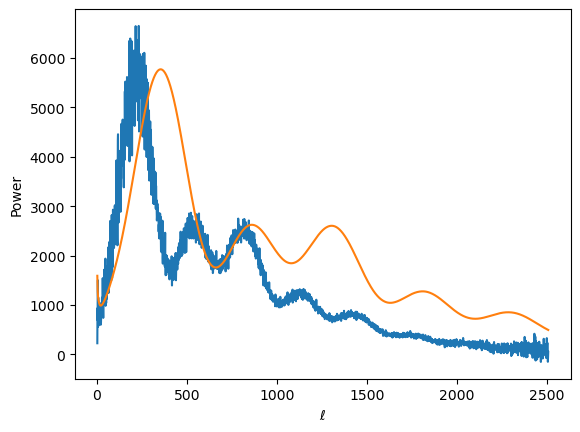

In [22]:
plt.plot(L,d_o)
plt.plot(L,dls[2])
plt.xlabel(r'$\ell$')
plt.ylabel("Power")

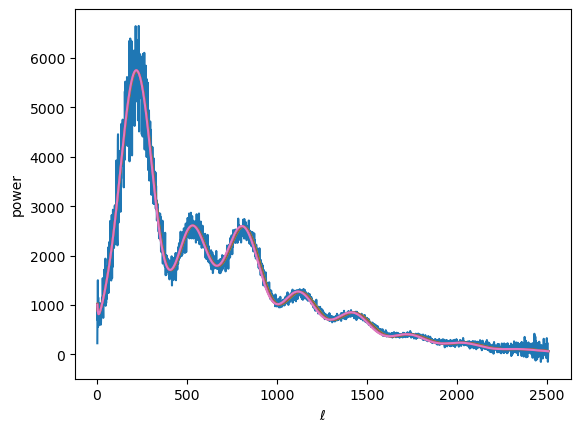

In [7]:
plt.plot(L,d_o)
for i in range(len(ms)):
    plt.plot(L, dls[i])
plt.xlabel(r'$\ell$')
plt.ylabel('power')
plt.show()

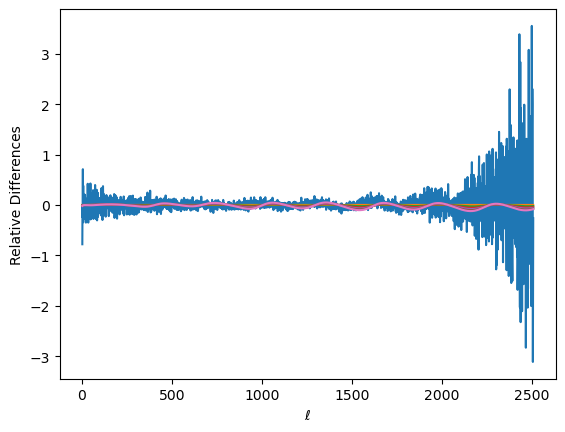

In [9]:
de=(d_o-dls[0])/dls[0]
plt.plot(L,de)
for i in range(len(ms)):
    delta= (dls[i]-dls[0])/dls[0]
    plt.plot(L, delta)
plt.xlabel(r'$\ell$')
plt.ylabel('Relative Differences')
plt.show()


IndexError: list index out of range

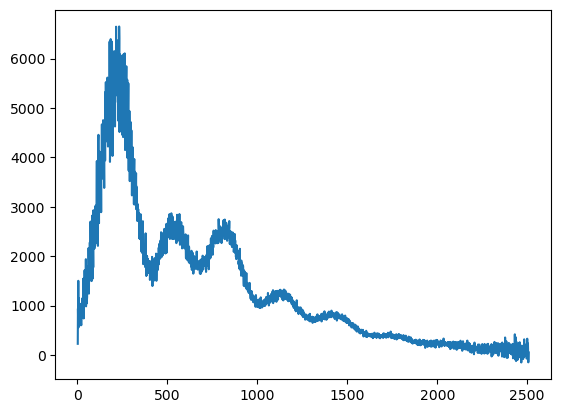

In [12]:
plt.plot(L,d_o)
plt.plot(L,dls[2])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell(\ell+1)T_0^2C_\ell/2\pi\quad[\mu K^2]$')


Text(0, 0.5, 'Likelihood')

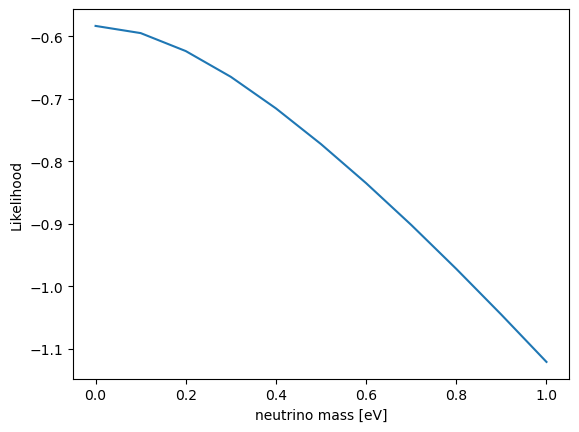

In [19]:
plt.plot(ms,likes)
plt.xlabel('neutrino mass [eV]')
plt.ylabel('Likelihood')

In [ ]:
plt.plot(L,d_o)
for i in range(len(ms)):
    plt.plot(L, dls[i])
plt.show()

In [9]:
print(type(cl))
cl.keys()

<class 'dict'>


dict_keys(['tt', 'pp', 'tp', 'ell'])

In [7]:
type(cls)
print(1)

1


In [26]:

for i in range(len(ks)):
    likes.append(loglikelihood(d_t))   
print(likes)

[-272707.19992885215, -272707.19992885215, -272707.19992885215]


In [17]:
loglikelihood(d_t)

-272707.1999282531